In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [52]:
BASE_PATH = './data/' 

faculty_raw     = pd.read_excel(BASE_PATH + 'faculty-list-2025.xlsx',
                                sheet_name='Sheet1')

abstract_raw    = pd.read_excel(BASE_PATH + 'grants-with-abstract.xlsx',
                                sheet_name='Grants with abstract (2).csv')

copi_raw        = pd.read_excel(BASE_PATH + 'grants-with-coPI.xlsx',
                                sheet_name='Grants with co PI indicator (1)')

ri_raw          = pd.read_excel(BASE_PATH + 'ri_matches_grants_2026.xlsx',
                                sheet_name='ri_matches_grants_2026-2-1_3-50')

print(f'  faculty      : {faculty_raw.shape}')
print(f'  abstract     : {abstract_raw.shape}')
print(f'  copi         : {copi_raw.shape}')
print(f'  ri_matches   : {ri_raw.shape}')

  faculty      : (2232, 9)
  abstract     : (8075, 25)
  copi         : (3136, 22)
  ri_matches   : (3146, 22)


In [53]:
print(' FACULTY COLUMNS AND DTYPES')
print(faculty_raw.dtypes)
print()
faculty_raw.head(5)

 FACULTY COLUMNS AND DTYPES
Employee ID                      int64
Superior_Academic_Unit          object
Superior_Academic_Unit_Code     object
Academic Unit                   object
Academic Track Type             object
Academic Rank                   object
Tenure Status                   object
Location_Address_Country        object
black                          float64
dtype: object



,Employee ID,Superior_Academic_Unit,Superior_Academic_Unit_Code,Academic Unit,Academic Track Type,Academic Rank,Tenure Status,Location_Address_Country,black
0,26501,College of Professional Studies,CC067,College of Professional Studies,Non-Tenure,Teaching Professor,NaN,United States of America,NaN
1,27481,College of Professional Studies,CC067,College of Professional Studies,Non-Tenure,Professor of the Practice,NaN,United States of America,NaN
2,27675,College of Engineering,CC044,Mechanical and Industrial Engineering,Non-Tenure,Associate Teaching Professor,NaN,United States of America,NaN
3,28441,Bouvé College of Health Sciences,CC004,Health Sciences,Non-Tenure,Assistant Teaching Professor,NaN,United States of America,NaN
4,30868,College of Professional Studies,CC067,College of Professional Studies,Non-Tenure,Associate Teaching Professor,NaN,United States of America,NaN


In [54]:
print('ABSTRACT FILE COLUMNS AND DTYPES')
print(abstract_raw.dtypes)
print()
abstract_raw.head(3)

ABSTRACT FILE COLUMNS AND DTYPES
Id                                                         int64
PersonId                                                   int64
Sourcetype                                                object
SourceActivityId                                          object
DesiredVisibility                                          int64
CreatedDate                                       datetime64[ns]
UpdatedDate                                       datetime64[ns]
DeprecatedDate                                           float64
Start Date                                        datetime64[ns]
End Date                                          datetime64[ns]
Ongoing                                                  float64
Title                                                     object
Sponsor                                                  float64
Dollar Amount                                              int64
Funding Status                                           

,Id,PersonId,Sourcetype,SourceActivityId,DesiredVisibility,CreatedDate,UpdatedDate,DeprecatedDate,Start Date,End Date,Ongoing,Title,Sponsor,Dollar Amount,Funding Status,Proposal/Award/Contract ID,University Grant ID,URL/Link,Abstract,AACSB - Type of Intellectual Contribution,AACSB - Mission,AACSB - Portfolio of Intellectual Contribution,Type of Funding,Funding Source,Community-engaged activity?
0,91740,15186,AA,131902,2,2019-04-12 06:02:00,NaT,NaN,2005-07-01,2009-06-30,NaN,Some determinants of speech perception,NaN,941956,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,91741,15486,AA,1169275,2,2019-04-12 06:02:00,NaT,NaN,2016-09-15,2019-08-31,NaN,TWC: Small: Collaborative: An Iterative Approach to Secure Computation,NaN,265954,1.00,NaN,NaN,NaN,Secure multi-party computation (MPC) allows several mutually untrusting part...,NaN,NaN,NaN,NaN,NaN,NaN
2,91708,15536,AA,1120636,2,2019-04-12 06:02:00,NaT,NaN,2016-08-01,2019-07-31,NaN,"CHS: Small: Collaborative Research: Teleoperation with Passive, Transparent ...",NaN,180000,1.00,NaN,NaN,NaN,Magnetic resonance imaging (MRI) is a widely used diagnostic tool that provi...,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
print('COPI FILE COLUMNS AND DTYPES')
print(copi_raw.dtypes)
print()
copi_raw.head(3)

COPI FILE COLUMNS AND DTYPES
GrantId                     int64
AgencyCode                 object
AgencyGrantId              object
GrantName                  object
DurationInYears           float64
AwardDate          datetime64[ns]
DollarsPerYear              int64
StartDate          datetime64[ns]
EndDate            datetime64[ns]
PersonId                    int64
ClientFacultyId             int64
PersonName                 object
OrcidId                    object
InstitutionName            object
PI                         object
TotalDollars                int64
IsResearch                  int64
AgencyName                 object
CountryCode                object
IsGovernment                int64
IsCoPI                      int64
StartDateYear               int64
dtype: object



,GrantId,AgencyCode,AgencyGrantId,GrantName,DurationInYears,AwardDate,DollarsPerYear,StartDate,EndDate,PersonId,ClientFacultyId,PersonName,OrcidId,InstitutionName,PI,TotalDollars,IsResearch,AgencyName,CountryCode,IsGovernment,IsCoPI,StartDateYear
0,38584,DOED,P200A040251,Graduate Assistance in Areas of National Need,3.33,2006-07-20,150000,2004-04-12,2007-08-14,272245,141701,"WADIA-FASCETTI, SARA J",NaN,Northeastern University,SARA J WADIA-FASCETTI,500000,1,Department Of Education,US,1,0,2004
1,42832,DOED,H133G070150,National Institute on Disability and Rehabilitation Research / Disability an...,3.08,2008-08-15,192753,2009-08-07,2012-09-30,271613,141778,"SCHLOSSER, RALF W",0000-0002-2069-3911,Northeastern University,RALF W SCHLOSSER,594324,1,Department Of Education,US,1,0,2009
2,43588,DOED,P016A070059,Undergraduate International Studies and Foreign Language Programs,2.00,2008-06-05,87419,2008-06-05,2010-06-30,88237,141136,"SULLIVAN, DENIS J",NaN,Northeastern University,DENIS SULLIVAN,174838,1,Department Of Education,US,1,0,2008


In [56]:
print('RI_MATCHES COLUMNS AND DTYPES')
print(ri_raw.dtypes)
print()
ri_raw.head(3)

RI_MATCHES COLUMNS AND DTYPES
grantid                     int64
agencycode                 object
agencygrantid              object
grantname                  object
durationinyears           float64
awarddate          datetime64[ns]
dollarsperyear              int64
startdate          datetime64[ns]
enddate            datetime64[ns]
AAUID                       int64
clientfacultyid             int64
orcid                      object
personname                 object
institutionname            object
pi                         object
totaldollars                int64
isresearch                  int64
agencyname                 object
countrycode                object
isgovernment                int64
iscopi                      int64
startdateyear               int64
dtype: object



,grantid,agencycode,agencygrantid,grantname,durationinyears,awarddate,dollarsperyear,startdate,enddate,AAUID,clientfacultyid,orcid,personname,institutionname,pi,totaldollars,isresearch,agencyname,countrycode,isgovernment,iscopi,startdateyear
0,1171240,NSF,9501172,CAREER: Architectural Support for Object-oriented Code Execution,2.92,NaT,45255,1995-06-01,1998-05-31,149515,148296,0000-0002-5692-0151,"KAELI, DAVID R",Northeastern University,"KAELI, DAVID",131995,1,National Science Foundation,US,1,0,1995
1,1171644,NSF,9702257,CAREER: Connecting the Engineering Profession and Society,5.42,NaT,66255,1997-07-01,2002-12-31,60253,2983576,0000-0002-6719-6023,"LESKO, JACK JAMES",Northeastern University,"LESKO, JOHN",358885,1,National Science Foundation,US,1,0,1997
2,1171799,NSF,9701998,CAREER: Driven Interfaces in Random Media,4.92,NaT,45294,1997-06-01,2002-05-31,6001,404727,0000-0002-4028-3522,"BARABASI, ALBERT-LASZLO",Northeastern University,"BARABASI, ALBERT-LASZLO",222700,1,National Science Foundation,US,1,0,1997


In [57]:
# Count nulls and null percentages for every column in every file
def null_report(df, name):
    total = len(df)
    miss  = df.isnull().sum()
    pct   = (miss / total * 100).round(1)
    report = pd.DataFrame({'nulls': miss, 'pct_null': pct, 'non_null': total - miss})
    report = report[report['nulls'] >= 0].sort_values('nulls', ascending=False)
    print(f'\n  {name} | {total:,} rows')
    print(report.to_string())
    return report

null_faculty   = null_report(faculty_raw,   'FACULTY')
null_abstract  = null_report(abstract_raw,  'ABSTRACT')
null_copi      = null_report(copi_raw,      'COPI')
null_ri        = null_report(ri_raw,        'RI_MATCHES')


  FACULTY | 2,232 rows
                             nulls  pct_null  non_null
black                         2232    100.00         0
Tenure Status                 1274     57.10       958
Employee ID                      0      0.00      2232
Superior_Academic_Unit           0      0.00      2232
Superior_Academic_Unit_Code      0      0.00      2232
Academic Unit                    0      0.00      2232
Academic Track Type              0      0.00      2232
Academic Rank                    0      0.00      2232
Location_Address_Country         0      0.00      2232

  ABSTRACT | 8,075 rows
                                                nulls  pct_null  non_null
Sponsor                                          8075    100.00         0
Ongoing                                          8075    100.00         0
Funding Source                                   8075    100.00         0
Type of Funding                                  8075    100.00         0
AACSB - Portfolio of Intellectu

In [58]:
# Identify completely empty columns (100% null) across all files
def dead_columns(df, name):
    dead = [c for c in df.columns if df[c].isnull().all()]
    print(f'{name}: {len(dead)} dead columns -> {dead}')
    return dead

dead_faculty  = dead_columns(faculty_raw,  'faculty')
dead_abstract = dead_columns(abstract_raw, 'abstract')
dead_copi     = dead_columns(copi_raw,     'copi')
dead_ri       = dead_columns(ri_raw,       'ri_matches')

faculty: 1 dead columns -> ['black']
abstract: 12 dead columns -> ['DeprecatedDate', 'Ongoing', 'Sponsor', 'Proposal/Award/Contract ID', 'University Grant ID', 'URL/Link', 'AACSB - Type of Intellectual Contribution', 'AACSB - Mission', 'AACSB - Portfolio of Intellectual Contribution', 'Type of Funding', 'Funding Source', 'Community-engaged activity?']
copi: 0 dead columns -> []
ri_matches: 0 dead columns -> []


In [59]:
# Drop dead columns and make clean working copies of each file
faculty   = faculty_raw.drop(columns=dead_faculty).copy()
abstract  = abstract_raw.drop(columns=dead_abstract).copy()
copi      = copi_raw.drop(columns=dead_copi).copy()
ri        = ri_raw.drop(columns=dead_ri).copy()

print('After dropping dead columns:')
print(f'  faculty    : {faculty_raw.shape} -> {faculty.shape}')
print(f'  abstract   : {abstract_raw.shape} -> {abstract.shape}')
print(f'  copi       : {copi_raw.shape} -> {copi.shape}')
print(f'  ri_matches : {ri_raw.shape} -> {ri.shape}')

After dropping dead columns:
  faculty    : (2232, 9) -> (2232, 8)
  abstract   : (8075, 25) -> (8075, 13)
  copi       : (3136, 22) -> (3136, 22)
  ri_matches : (3146, 22) -> (3146, 22)


In [60]:
# Parse all date columns to proper datetime objects
copi['StartDate'] = pd.to_datetime(copi['StartDate'], errors='coerce')
copi['EndDate']   = pd.to_datetime(copi['EndDate'],   errors='coerce')
copi['AwardDate'] = pd.to_datetime(copi['AwardDate'], errors='coerce')

ri['startdate']   = pd.to_datetime(ri['startdate'],   errors='coerce')
ri['enddate']     = pd.to_datetime(ri['enddate'],     errors='coerce')
ri['awarddate']   = pd.to_datetime(ri['awarddate'],   errors='coerce')

abstract['Start Date'] = pd.to_datetime(abstract['Start Date'], errors='coerce')
abstract['End Date']   = pd.to_datetime(abstract['End Date'],   errors='coerce')

print('Date columns parsed. Sample copi dates:')
print(copi[['StartDate','EndDate','AwardDate']].dtypes)

Date columns parsed. Sample copi dates:
StartDate    datetime64[ns]
EndDate      datetime64[ns]
AwardDate    datetime64[ns]
dtype: object


In [61]:
# Date range: earliest and latest start dates across files
print('Date ranges (start dates):')
print(f'  copi        : {copi["StartDate"].min().date()} to {copi["StartDate"].max().date()}')
print(f'  ri_matches  : {ri["startdate"].min().date()} to {ri["startdate"].max().date()}')
print(f'  abstract    : {abstract["Start Date"].min().date()} to {abstract["Start Date"].max().date()}')
print()
print('AwardDate populated rows:')
print(f'  copi        : {copi["AwardDate"].notna().sum():,} / {len(copi):,}')
print(f'  ri_matches  : {ri["awarddate"].notna().sum():,} / {len(ri):,}')

Date ranges (start dates):
  copi        : 1995-06-01 to 2026-01-01
  ri_matches  : 1995-06-01 to 2026-01-01
  abstract    : 1995-06-01 to 2026-01-01

AwardDate populated rows:
  copi        : 49 / 3,136
  ri_matches  : 49 / 3,146


In [62]:
# Check for date logic errors: end date before start date
bad_dates_copi     = copi[copi['EndDate'] < copi['StartDate']]
bad_dates_ri       = ri[ri['enddate'] < ri['startdate']]
bad_dates_abstract = abstract[abstract['End Date'] < abstract['Start Date']]

print(f'copi     end < start : {len(bad_dates_copi)} rows')
print(f'ri       end < start : {len(bad_dates_ri)} rows')
print(f'abstract end < start : {len(bad_dates_abstract)} rows')

if len(bad_dates_abstract):
    print('\nAbstract bad date rows:')
    print(bad_dates_abstract[['Id','Title','Start Date','End Date']])

copi     end < start : 0 rows
ri       end < start : 0 rows
abstract end < start : 1 rows

Abstract bad date rows:
          Id  \
4749  114092   

                                                                            Title  \
4749  Global Trade Movements Anti-Money Laundering & Counterproliferation Project   

     Start Date   End Date  
4749 2013-10-08 2013-09-30  


In [63]:
# Check for far-future end dates (beyond 2030)
far_future_copi = copi[copi['EndDate'] > pd.Timestamp('2030-01-01')]
far_future_ri   = ri[ri['enddate'] > pd.Timestamp('2030-01-01')]

print(f'copi EndDate > 2030 : {len(far_future_copi)} rows')
print(f'ri   enddate > 2030 : {len(far_future_ri)} rows')
print()
print('Sample far-future copi rows:')
far_future_copi[['GrantName','StartDate','EndDate','DurationInYears']].head(5)

copi EndDate > 2030 : 20 rows
ri   enddate > 2030 : 20 rows

Sample far-future copi rows:


,GrantName,StartDate,EndDate,DurationInYears
3014,"CAREER: Emergent Phases: Fracton, Symmetry, and Decoherence",2025-06-01,2030-05-31,4.92
3020,CAREER: Mechanism-Informed AI for Biological Systems-of-Systems to Accelerat...,2025-09-01,2030-08-31,4.92
3021,"CAREER: Sublinear-Time Graph Algorithms: Foundations, Limitations, and Conne...",2025-05-01,2030-04-30,4.92
3022,CAREER: Cryogenic-CMOS and Superconducting Circuits for Scalable Quantum Sys...,2025-02-01,2030-01-31,4.92
3023,CAREER: Formal Verification of Stateful Distributed Systems and Their Compos...,2025-05-01,2030-04-30,4.92


DurationInYears stats (copi):
count   3,136.00
mean        3.45
std         1.80
min         1.00
25%         1.92
50%         3.33
75%         4.75
max        20.08
Name: DurationInYears, dtype: float64

Duration <= 0  : 0
Duration  1-5  : 2834
Duration  5-10 : 279
Duration > 10  : 23


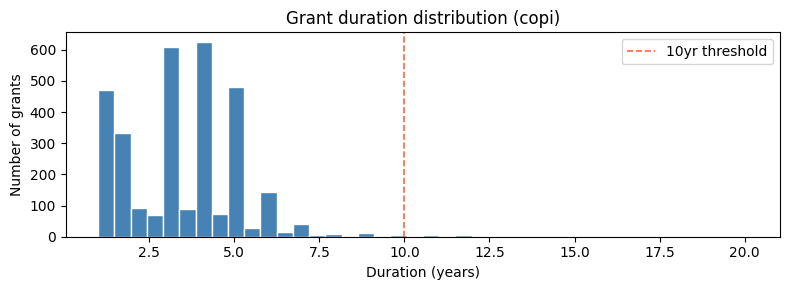

In [64]:
# Distribution of grant duration in years (copi) — flag outliers above 10 years
print('DurationInYears stats (copi):')
print(copi['DurationInYears'].describe())
print()
print(f'Duration <= 0  : {(copi["DurationInYears"] <= 0).sum()}')
print(f'Duration  1-5  : {((copi["DurationInYears"] > 0) & (copi["DurationInYears"] <= 5)).sum()}')
print(f'Duration  5-10 : {((copi["DurationInYears"] > 5) & (copi["DurationInYears"] <= 10)).sum()}')
print(f'Duration > 10  : {(copi["DurationInYears"] > 10).sum()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(copi['DurationInYears'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(10, color='tomato', linestyle='--', linewidth=1.2, label='10yr threshold')
ax.set_xlabel('Duration (years)')
ax.set_ylabel('Number of grants')
ax.set_title('Grant duration distribution (copi)')
ax.legend()
plt.tight_layout()
plt.show()

In [65]:
# Dollar amount analysis, grants_abstract file
# The abstract file has two source types with very different dollar behavior
print('Dollar Amount stats — full abstract file:')
print(abstract['Dollar Amount'].describe())
print()
print('By Sourcetype:')
print(abstract.groupby('Sourcetype')['Dollar Amount'].describe())
print()
print('Zero-dollar rows by Sourcetype:')
print(abstract.groupby('Sourcetype').apply(lambda x: (x['Dollar Amount'] == 0).sum()).rename('zero_dollar_rows'))

Dollar Amount stats — full abstract file:
count        8,075.00
mean       436,261.71
std      1,845,591.43
min              0.00
25%              0.00
50%              0.00
75%        359,980.00
max     39,845,551.00
Name: Dollar Amount, dtype: float64

By Sourcetype:
               count       mean          std    min        25%        50%  \
Sourcetype                                                                  
AA          3,583.00 983,202.14 2,672,050.26 580.00 192,493.00 416,568.00   
Institution 4,492.00       0.00         0.00   0.00       0.00       0.00   

                   75%           max  
Sourcetype                            
AA          769,400.00 39,845,551.00  
Institution       0.00          0.00  

Zero-dollar rows by Sourcetype:
Sourcetype
AA                0
Institution    4492
Name: zero_dollar_rows, dtype: int64


TotalDollars stats (copi):
count        3,136.00
mean       846,928.89
std      1,833,749.22
min            527.00
25%        199,999.00
50%        429,134.00
75%        771,030.75
max     38,461,679.00
Name: TotalDollars, dtype: float64

Zero TotalDollars    : 0
Negative TotalDollars: 0
Total funding in file: $2,655,969,005
Mean per grant row   : $846,929
Median per grant row : $429,134


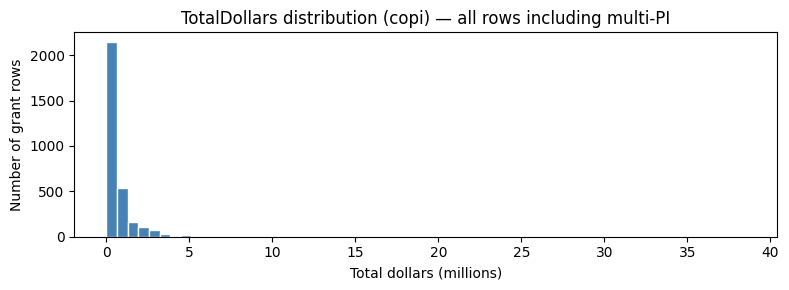

In [66]:
# Dollar amount analysis — copi file
print('TotalDollars stats (copi):')
print(copi['TotalDollars'].describe())
print()
print(f'Zero TotalDollars    : {(copi["TotalDollars"] == 0).sum()}')
print(f'Negative TotalDollars: {(copi["TotalDollars"] < 0).sum()}')
print(f'Total funding in file: ${copi["TotalDollars"].sum():,.0f}')
print(f'Mean per grant row   : ${copi["TotalDollars"].mean():,.0f}')
print(f'Median per grant row : ${copi["TotalDollars"].median():,.0f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(copi['TotalDollars'] / 1e6, bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('Total dollars (millions)')
ax.set_ylabel('Number of grant rows')
ax.set_title('TotalDollars distribution (copi) — all rows including multi-PI')
plt.tight_layout()
plt.show()

In [67]:
# Identify duplicate GrantIds in copi — these are multi-person grants
# vs true duplicate rows (same GrantId AND same PersonId)
dup_grantid     = copi['GrantId'].duplicated(keep=False)
dup_grant_person = copi.duplicated(['GrantId', 'PersonId'], keep=False)

print(f'Rows with a duplicated GrantId (multi-person grants): {dup_grantid.sum()}')
print(f'Unique GrantIds involved                            : {copi[dup_grantid]["GrantId"].nunique()}')
print()
print(f'True duplicate rows (same GrantId + PersonId)       : {dup_grant_person.sum()}')
print()
print('Sample multi-person grant:')
sample_dup = copi[dup_grantid].sort_values('GrantId').head(6)
print(sample_dup[['GrantId','PersonName','IsCoPI','TotalDollars']].to_string(index=False))

Rows with a duplicated GrantId (multi-person grants): 780
Unique GrantIds involved                            : 314

True duplicate rows (same GrantId + PersonId)       : 10

Sample multi-person grant:
 GrantId             PersonName  IsCoPI  TotalDollars
  111663 VESPIGNANI, ALESSANDRO       0        883979
  111663 VESPIGNANI, ALESSANDRO       1        883979
  315120         BUDIL, DAVID E       1        131870
  315120      MUKERJEE, SANJEEV       1        131870
  317127        JUNG, YUNG JOON       0        120001
  317127        BUSNAINA, AHMED       1        120001


In [68]:
# Same duplicate check for ri_matches
dup_ri_grantid      = ri['grantid'].duplicated(keep=False)
dup_ri_grant_person = ri.duplicated(['grantid', 'AAUID'], keep=False)

print(f'ri: rows with duplicated grantid                 : {dup_ri_grantid.sum()}')
print(f'ri: unique grantids involved                     : {ri[dup_ri_grantid]["grantid"].nunique()}')
print(f'ri: true duplicates (grantid + AAUID)            : {dup_ri_grant_person.sum()}')

ri: rows with duplicated grantid                 : 786
ri: unique grantids involved                     : 316
ri: true duplicates (grantid + AAUID)            : 12


In [69]:
# Duplicate check for grants_abstract: same PersonId + Title appearing more than once
dup_abstract_person_title = abstract.duplicated(['PersonId', 'Title'], keep=False)
dup_abstract_id = abstract.duplicated('Id', keep=False)

print(f'abstract: duplicate (PersonId + Title) rows : {dup_abstract_person_title.sum()}')
print(f'abstract: duplicate Id (record id) rows     : {dup_abstract_id.sum()}')
print()
print('Sample duplicated (PersonId + Title):')
abstract[dup_abstract_person_title].sort_values(['PersonId','Title'])[['Id','PersonId','Title','Dollar Amount','Start Date']].head(6)

abstract: duplicate (PersonId + Title) rows : 961
abstract: duplicate Id (record id) rows     : 0

Sample duplicated (PersonId + Title):


,Id,PersonId,Title,Dollar Amount,Start Date
7180,116464,1183,A Synthetic Electronics Route to Scalable and Competitive Molecular Qubit Sy...,0,2023-08-21
7184,116470,1183,A Synthetic Electronics Route to Scalable and Competitive Molecular Qubit Sy...,0,2024-09-01
2452,94684,1183,Center for Molecular Magnetic Quantum Materials,4667000,2018-08-01
7175,116459,1183,Center for Molecular Magnetic Quantum Materials,0,2023-08-01
3093,94953,1183,Collaborative Research: Center for Coatings Research,327215,2023-09-01
3124,94963,1183,Collaborative Research: Center for Coatings Research,354215,2024-05-01


In [70]:
# Sourcetype breakdown in grants_abstract
# 'AA' = agency-verified records with real dollar amounts
# 'Institution' = self-reported, all $0 — treat as separate subset
print('Sourcetype counts:')
print(abstract['Sourcetype'].value_counts())
print()
print('Funding Status by Sourcetype:')
print(abstract.groupby('Sourcetype')['Funding Status'].value_counts(dropna=False))

Sourcetype counts:
Sourcetype
Institution    4492
AA             3583
Name: count, dtype: int64

Funding Status by Sourcetype:
Sourcetype   Funding Status
AA           1.00              3551
             NaN                 32
Institution  NaN               2264
             2.00              2228
Name: count, dtype: int64


In [71]:
# Funding Status codes in grants_abstract — values are numeric (1.0, 2.0), meaning unknown
print('Funding Status value counts (abstract):')
print(abstract['Funding Status'].value_counts(dropna=False))
print()
print(f'Total rows                 : {len(abstract):,}')
print(f'Status = 1.0               : {(abstract["Funding Status"] == 1.0).sum():,}')
print(f'Status = 2.0               : {(abstract["Funding Status"] == 2.0).sum():,}')
print(f'Status null                : {abstract["Funding Status"].isnull().sum():,}')
#'status codes 1.0 / 2.0 have no legend in the file — meaning is unknown.

Funding Status value counts (abstract):
Funding Status
1.00    3551
NaN     2296
2.00    2228
Name: count, dtype: int64

Total rows                 : 8,075
Status = 1.0               : 3,551
Status = 2.0               : 2,228
Status null                : 2,296


In [72]:
# Abstract text availability — only AA source rows have abstracts
total_rows      = len(abstract)
has_abstract    = abstract['Abstract'].notna().sum()
missing_abstract = abstract['Abstract'].isnull().sum()
aa_rows         = (abstract['Sourcetype'] == 'AA').sum()
aa_with_abstract = abstract[(abstract['Sourcetype']=='AA') & abstract['Abstract'].notna()].shape[0]

print(f'Total rows in abstract file          : {total_rows:,}')
print(f'Rows with abstract text              : {has_abstract:,}  ({has_abstract/total_rows*100:.1f}%)')
print(f'Rows missing abstract text           : {missing_abstract:,}  ({missing_abstract/total_rows*100:.1f}%)')
print()
print(f'AA source rows                       : {aa_rows:,}')
print(f'AA rows with abstract text           : {aa_with_abstract:,}  ({aa_with_abstract/aa_rows*100:.1f}% of AA rows)')
# NLP / topic modeling can only use AA rows with abstracts

Total rows in abstract file          : 8,075
Rows with abstract text              : 2,873  (35.6%)
Rows missing abstract text           : 5,202  (64.4%)

AA source rows                       : 3,583
AA rows with abstract text           : 2,873  (80.2% of AA rows)


In [73]:
# PI name format inconsistency in copi
# PersonName = Northeastern faculty (LAST, FIRST format)
# PI = grant-listed PI (mixed formats, sometimes a different person)
print('PersonName vs PI — they are NOT always the same person:')
print('PersonName is the NU faculty member; PI is the official grant PI (could be external).')
print()
print('Sample of rows where PersonName != PI:')
diff_pi = copi[copi['PersonName'].str.upper() != copi['PI'].str.upper()]
print(f'  Rows where PersonName != PI : {len(diff_pi):,} / {len(copi):,}')
print()
print(diff_pi[['PersonName','PI','IsCoPI']].head(10).to_string(index=False))

PersonName vs PI — they are NOT always the same person:
PersonName is the NU faculty member; PI is the official grant PI (could be external).

Sample of rows where PersonName != PI:
  Rows where PersonName != PI : 2,321 / 3,136

               PersonName                    PI  IsCoPI
   WADIA-FASCETTI, SARA J SARA J WADIA-FASCETTI       0
        SCHLOSSER, RALF W      RALF W SCHLOSSER       0
        SULLIVAN, DENIS J        DENIS SULLIVAN       0
          CHENG, HAI-PING        HAI-PING CHENG       0
  BEIGHLEY, EDWARD EDWARD      beighley, edward       0
MANOLIOS, PANAGIOTIS PETE  MANOLIOS, PANAGIOTIS       0
MANOLIOS, PANAGIOTIS PETE  MANOLIOS, PANAGIOTIS       0
   AUGUSTE, DEBRA THERESA        AUGUSTE, DEBRA       0
            CHEN, JIM JIM      CHEN, DR QIN JIM       0
            CHEN, JIM JIM      CHEN, DR QIN JIM       0


In [74]:
# PI name format: check for mixed case, lowercase, all-caps
pi_lower  = copi[copi['PI'].str.strip().str.islower()]
pi_upper  = copi[copi['PI'].str.strip().str.isupper()]
pi_mixed  = copi[~copi['PI'].str.strip().str.isupper() & ~copi['PI'].str.strip().str.islower()]

print(f'PI name all-uppercase  : {len(pi_upper):,}')
print(f'PI name mixed-case     : {len(pi_mixed):,}')
print(f'PI name all-lowercase  : {len(pi_lower):,}')
print()
print('Lowercase PI examples:')
print(pi_lower[['PersonName','PI']].head(5).to_string(index=False))
print()
print('Mixed-case PI examples:')
print(pi_mixed[['PersonName','PI']].head(5).to_string(index=False))

PI name all-uppercase  : 760
PI name mixed-case     : 2,375
PI name all-lowercase  : 1

Lowercase PI examples:
             PersonName               PI
BEIGHLEY, EDWARD EDWARD beighley, edward

Mixed-case PI examples:
           PersonName                    PI
BARRETT, LISA FELDMAN Barrett, Lisa Feldman
BARRETT, LISA FELDMAN Barrett, Lisa Feldman
       LINCOLN, ALISA      Lincoln, Alisa K
   ASTHAGIRI, ANAND R    Asthagiri, Anand R
   MOLNAR, BETH ELLEN    Molnar, Beth Ellen


In [75]:
# ORCID coverage — useful for cross-referencing with external research databases
print('ORCID coverage:')
print(f'  copi      : {copi["OrcidId"].notna().sum():,} / {len(copi):,} rows  ({copi["OrcidId"].notna().mean()*100:.1f}%)')
print(f'  ri_matches: {ri["orcid"].notna().sum():,} / {len(ri):,} rows  ({ri["orcid"].notna().mean()*100:.1f}%)')
print()
print('ORCID format check (should be 0000-0000-0000-0000):')
valid_fmt = copi['OrcidId'].dropna().str.match(r'^\d{4}-\d{4}-\d{4}-\d{3}[\dX]$')
print(f'  copi valid ORCID format: {valid_fmt.sum()} / {valid_fmt.count()}')

ORCID coverage:
  copi      : 2,807 / 3,136 rows  (89.5%)
  ri_matches: 2,816 / 3,146 rows  (89.5%)

ORCID format check (should be 0000-0000-0000-0000):
  copi valid ORCID format: 2807 / 2807


In [76]:
# Faculty file — Tenure Status is 57% null because Non-Tenure track rows have no status
print('Faculty Tenure Status breakdown:')
print(faculty['Tenure Status'].value_counts(dropna=False))
print()
print('Academic Track Type breakdown:')
print(faculty['Academic Track Type'].value_counts(dropna=False))
print()
# Show which tracks have null Tenure Status
print('Null Tenure Status by Track Type:')
print(faculty.groupby('Academic Track Type')['Tenure Status'].apply(lambda x: x.isnull().sum()).sort_values(ascending=False))

Faculty Tenure Status breakdown:
Tenure Status
NaN                1274
Tenured             646
Tenure Track        288
Tenure On Entry      24
Name: count, dtype: int64

Academic Track Type breakdown:
Academic Track Type
Non-Tenure                  1079
Tenure Track                 958
Teaching and Scholarship      81
Visiting Lecturers            53
Teaching and Research         47
Teaching Only                 10
Research Only                  4
Name: count, dtype: int64

Null Tenure Status by Track Type:
Academic Track Type
Non-Tenure                  1079
Teaching and Scholarship      81
Visiting Lecturers            53
Teaching and Research         47
Teaching Only                 10
Research Only                  4
Tenure Track                   0
Name: Tenure Status, dtype: int64


Faculty count by college:
Superior_Academic_Unit
College of Engineering                       356
College of Science                           332
College of Social Sciences and Humanities    304
Bouvé College of Health Sciences             269
D'Amore-McKim School of Business             215
College of Arts, Media and Design            210
Khoury College of Computer Sciences          210
Northeastern University London               126
College of Professional Studies              110
School of Law                                 58
Mills College at Northeastern                 40
Northeastern University                        2

Total faculty: 2,232
Unique colleges: 12


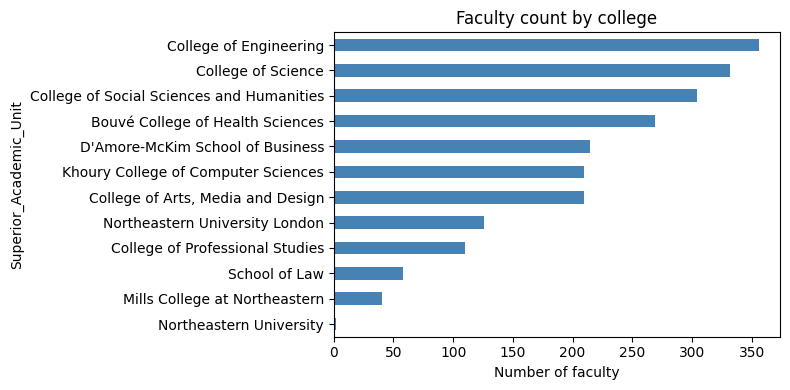

In [77]:
# Faculty by college
print('Faculty count by college:')
college_counts = faculty['Superior_Academic_Unit'].value_counts()
print(college_counts.to_string())
print(f'\nTotal faculty: {len(faculty):,}')
print(f'Unique colleges: {faculty["Superior_Academic_Unit"].nunique()}')

fig, ax = plt.subplots(figsize=(8, 4))
college_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of faculty')
ax.set_title('Faculty count by college')
plt.tight_layout()
plt.show()

In [78]:
# Cross-file check: how much do copi and ri_matches overlap?
# They look like the same data exported twice ?
copi_grant_ids = set(copi['GrantId'].astype(str))
ri_grant_ids   = set(ri['grantid'].astype(str))

in_both   = copi_grant_ids & ri_grant_ids
only_copi = copi_grant_ids - ri_grant_ids
only_ri   = ri_grant_ids - copi_grant_ids

print('Grant ID overlap between copi and ri_matches:')
print(f'  Unique GrantIds in copi        : {len(copi_grant_ids):,}')
print(f'  Unique GrantIds in ri_matches  : {len(ri_grant_ids):,}')
print(f'  In BOTH files                  : {len(in_both):,}')
print(f'  Only in copi                   : {len(only_copi):,}  -> {list(only_copi)}')
print(f'  Only in ri_matches             : {len(only_ri):,}  -> {list(only_ri)[:5]}')
print()
# files are near-identical, Use copi as primary (links to faculty via ClientFacultyId)

Grant ID overlap between copi and ri_matches:
  Unique GrantIds in copi        : 2,670
  Unique GrantIds in ri_matches  : 2,676
  In BOTH files                  : 2,666
  Only in copi                   : 4  -> ['1724816', '1785538', '1761345', '1722677']
  Only in ri_matches             : 10  -> ['945928', '1797758', '1796096', '1357166', '1796648']



In [79]:
# Faculty ID linkage: can we join copi to faculty?
# copi.ClientFacultyId should match faculty.Employee_ID
matched_copi   = copi['ClientFacultyId'].isin(faculty['Employee ID'])
unmatched_copi = ~matched_copi

print('copi -> faculty match via ClientFacultyId -> Employee ID:')
print(f'  Matched rows   : {matched_copi.sum():,} / {len(copi):,}  ({matched_copi.mean()*100:.1f}%)')
print(f'  Unmatched rows : {unmatched_copi.sum():,}')
print()
unmatched_people = copi[unmatched_copi]['PersonName'].unique()
print(f'  Unique people unmatched: {len(unmatched_people)}')
# These are likely departed faculty not in the 2025 roster
print()
print('Unmatched names:')
print(list(unmatched_people))

copi -> faculty match via ClientFacultyId -> Employee ID:
  Matched rows   : 2,959 / 3,136  (94.4%)
  Unmatched rows : 177

  Unique people unmatched: 27

Unmatched names:
['WADIA-FASCETTI, SARA J', 'SCHLOSSER, RALF W', 'KRAMER, ART F', 'MACINTYRE, BLAIR', 'SUN, NIAN', 'SHEAHAN, THOMAS C', 'ROLLE, MARSHA WHITNEY', 'DUGGAN, CLAIRE', 'HENDERSON, KEN WILLIAM', 'ISAACS, JACKIE A', 'LUZZI, DAVID E', 'TSAI, KELLEE', 'ABOWD, GREGORY DOMINIC', 'ENGEN, JOHN R', 'POLLASTRI, MICHAEL P', 'PORTER, RICHARD D', 'VOLLMER, STEVEN V', 'HARRIS, RICHARD', 'SCEPPA, CARMEN C', 'KNUDSEN, BEN ERIC', 'PIEPER, KELSEY JANETTE', 'TIP, FRANK', 'TIWARI, DEVESH', 'GOSAIN, MANU', 'JOHARI, PEDRAM', 'ABI HASSAN ABDUL SAMAD, SAHAR CHIQUINQUIRA', 'ANDERSON, ERIC WILLIAM']


In [80]:
# ri_matches uses AAUID — does it match faculty Employee ID?
matched_ri   = ri['AAUID'].isin(faculty['Employee ID'])
unmatched_ri = ~matched_ri

print('ri_matches -> faculty match via AAUID -> Employee ID:')
print(f'  Matched rows   : {matched_ri.sum():,} / {len(ri):,}  ({matched_ri.mean()*100:.1f}%)')
print(f'  Unmatched rows : {unmatched_ri.sum():,}')
print()

# Conclusion: AAUID is a DIFFERENT ID system than Employee ID.
# ri_matches cannot be directly joined to the faculty file.
# Use copi for faculty-linked analysis.

ri_matches -> faculty match via AAUID -> Employee ID:
  Matched rows   : 6 / 3,146  (0.2%)
  Unmatched rows : 3,140



In [81]:
# Can we join grants_abstract to copi? Check shared identifier options
# abstract has: Id, PersonId, SourceActivityId
# copi has: GrantId, PersonId, AgencyGrantId

# Check PersonId overlap
abstract_persons = set(abstract['PersonId'].dropna().astype(str))
copi_persons     = set(copi['PersonId'].dropna().astype(str))

print('PersonId overlap between abstract and copi:')
print(f'  abstract PersonIds : {len(abstract_persons):,}')
print(f'  copi PersonIds     : {len(copi_persons):,}')
print(f'  in both            : {len(abstract_persons & copi_persons):,}')
print()

# Check SourceActivityId vs AgencyGrantId
abstract_source = set(abstract['SourceActivityId'].dropna().astype(str))
copi_agency     = set(copi['AgencyGrantId'].dropna().astype(str))
print('SourceActivityId (abstract) vs AgencyGrantId (copi):')
print(f'  overlap: {len(abstract_source & copi_agency):,}')

# No reliable shared key for a direct join. Abstract text must be matched to copi via fuzzy title matching or PersonId + year.

PersonId overlap between abstract and copi:
  abstract PersonIds : 1,042
  copi PersonIds     : 567
  in both            : 0

SourceActivityId (abstract) vs AgencyGrantId (copi):
  overlap: 2


In [82]:
# Build the clean analysis-ready version of copi
# deduplicate so each grant appears once (keep PI row; if no PI row, keep first)
# This prevents double-counting dollars when aggregating by grant

# Sort so PI rows (IsCoPI=0) come first, then deduplicate on GrantId
copi_sorted   = copi.sort_values(['GrantId', 'IsCoPI'])  # PI=0 floats to top
copi_deduped  = copi_sorted.drop_duplicates(subset='GrantId', keep='first').copy()

print(f'copi before dedup : {len(copi):,} rows')
print(f'copi after dedup  : {len(copi_deduped):,} rows  (one row per unique grant)')
print()
print(f'Total unique grants        : {len(copi_deduped):,}')
print(f'Total funding (deduped)    : ${copi_deduped["TotalDollars"].sum():,.0f}')
print(f'Total funding (raw, overcounted) : ${copi["TotalDollars"].sum():,.0f}')

copi before dedup : 3,136 rows
copi after dedup  : 2,670 rows  (one row per unique grant)

Total unique grants        : 2,670
Total funding (deduped)    : $2,148,999,021
Total funding (raw, overcounted) : $2,655,969,005


In [83]:
# Merge deduped grants onto faculty to get college for each grant
faculty_slim = faculty[['Employee ID', 'Superior_Academic_Unit', 'Academic Track Type', 'Academic Rank']].copy()
faculty_slim = faculty_slim.rename(columns={'Employee ID': 'ClientFacultyId'})

copi_with_college = copi_deduped.merge(faculty_slim, on='ClientFacultyId', how='left')

matched   = copi_with_college['Superior_Academic_Unit'].notna().sum()
unmatched = copi_with_college['Superior_Academic_Unit'].isnull().sum()

print(f'Grants matched to a college  : {matched:,}  ({matched/len(copi_with_college)*100:.1f}%)')
print(f'Grants with no college match : {unmatched:,}  (departed faculty)')
print()
print('College distribution of grants:')
print(copi_with_college['Superior_Academic_Unit'].value_counts(dropna=False).to_string())

Grants matched to a college  : 2,530  (94.8%)
Grants with no college match : 140  (departed faculty)

College distribution of grants:
Superior_Academic_Unit
College of Engineering                       957
College of Science                           749
Khoury College of Computer Sciences          359
Bouvé College of Health Sciences             275
NaN                                          140
College of Social Sciences and Humanities    115
College of Arts, Media and Design             46
School of Law                                 10
D'Amore-McKim School of Business               9
Northeastern University                        6
College of Professional Studies                4


                                           num_grants  total_M    avg_grant
Superior_Academic_Unit                                                     
College of Engineering                            957   771.90   806,572.68
College of Science                                749   573.70   765,992.20
Bouvé College of Health Sciences                  275   367.70 1,337,117.24
Khoury College of Computer Sciences               359   214.50   597,459.72
NaN                                               140   109.60   782,879.71
College of Social Sciences and Humanities         115    65.40   568,459.97
College of Arts, Media and Design                  46    27.70   601,143.65
School of Law                                      10     9.00   898,362.00
College of Professional Studies                     4     5.00 1,259,413.00
D'Amore-McKim School of Business                    9     3.30   371,726.44
Northeastern University                             6     1.20   198,340.83


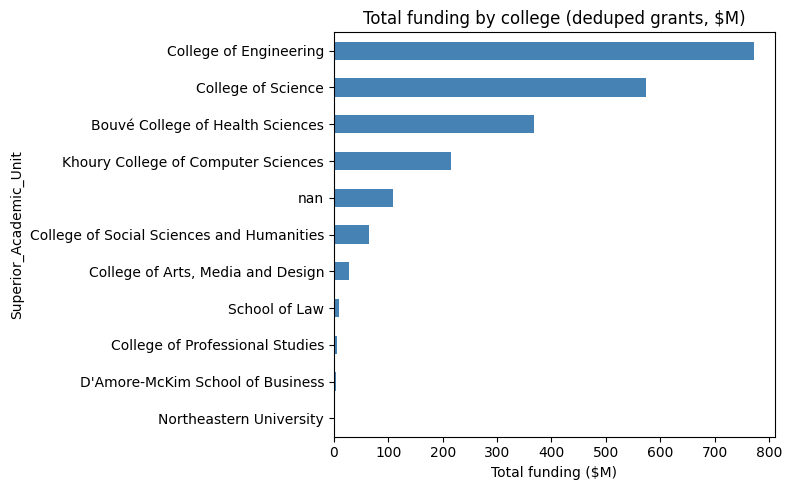

In [84]:
# Total funding per college (deduped, one row per grant)
funding_by_college = (
    copi_with_college
    .groupby('Superior_Academic_Unit', dropna=False)['TotalDollars']
    .agg(['sum','count','mean'])
    .rename(columns={'sum':'total_dollars','count':'num_grants','mean':'avg_grant'})
    .sort_values('total_dollars', ascending=False)
)
funding_by_college['total_M'] = (funding_by_college['total_dollars'] / 1e6).round(1)
print(funding_by_college[['num_grants','total_M','avg_grant']].to_string())

fig, ax = plt.subplots(figsize=(8, 5))
funding_by_college['total_M'].dropna().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total funding ($M)')
ax.set_title('Total funding by college (deduped grants, $M)')
plt.tight_layout()
plt.show()

In [85]:
# Unique PI count and funding concentration
# How many PIs account for the top 80% of total funding?
pi_funding = (
    copi_deduped
    .groupby('PersonName')['TotalDollars']
    .sum()
    .sort_values(ascending=False)
)

total_all    = pi_funding.sum()
cumulative   = pi_funding.cumsum() / total_all
top80_count  = (cumulative <= 0.80).sum() + 1

print(f'Unique PIs in copi file      : {pi_funding.shape[0]:,}')
print(f'Total funding across all PIs : ${total_all:,.0f}')
print(f'PIs needed for top 80%       : {top80_count} out of {pi_funding.shape[0]}')
print()
print('Top 20 PIs by total funding:')
print(pi_funding.head(20).apply(lambda x: f'${x:,.0f}').to_string())

Unique PIs in copi file      : 532
Total funding across all PIs : $2,148,999,021
PIs needed for top 80%       : 173 out of 532

Top 20 PIs by total funding:
PersonName
ALSHAWABKEH, AKRAM N         $83,566,334
MELODIA, TOMMASO             $79,730,782
MAKRIYANNIS, ALEXANDROS      $60,198,469
LEVINE, HERBERT              $46,226,708
QUARANTA, VITO               $45,230,423
LEWIS, KIM                   $44,863,052
WINSLOW, RAI LESTER          $40,300,548
ABUR, ALI                    $38,745,428
BRONICH, TATIANA KARPOVNA    $33,482,077
TORCHILIN, VLADIMIR P        $28,793,148
BUSNAINA, AHMED              $26,338,228
BARRETT, LISA FELDMAN        $25,250,844
SEITZ, AARON                 $22,785,568
MINGOLLA, ENNIO              $22,279,326
KAELI, DAVID R               $20,491,570
LAZER, DAVID M J             $19,863,775
FIETE, GREGORY A             $19,248,738
BICKMORE, TIMOTHY W          $18,187,616
KRAMER, ART F                $17,706,568
WADIA-FASCETTI, SARA J       $16,878,830


Funding agencies:
                                                        num_grants  pct_grants  total_M
AgencyName                                                                             
National Science Foundation                                   1682       63.00 1,049.40
National Institutes of Health                                  546       20.40   833.00
National Institutes of Health - SubAward                       104        3.90    74.60
Office of Naval Research                                        87        3.30    59.70
National Aeronautics and Space Administration                   49        1.80    22.10
Army Research Office                                            48        1.80    13.20
Department Of Energy                                            37        1.40    33.80
Air Force Research Office                                       31        1.20    11.40
Dept. Health and Human Services                                 21        0.80    32.50
National Endow

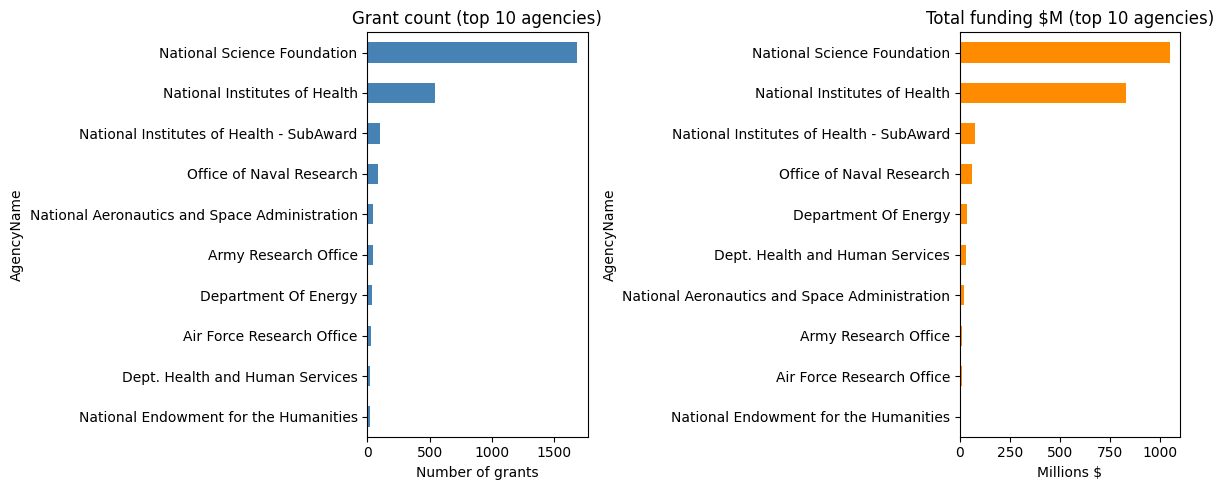

In [86]:
# Funding agency breakdown, number of grants and total dollars
agency_summary = (
    copi_deduped
    .groupby('AgencyName')['TotalDollars']
    .agg(['count','sum'])
    .rename(columns={'count':'num_grants','sum':'total_dollars'})
    .sort_values('num_grants', ascending=False)
)
agency_summary['total_M']   = (agency_summary['total_dollars'] / 1e6).round(1)
agency_summary['pct_grants'] = (agency_summary['num_grants'] / agency_summary['num_grants'].sum() * 100).round(1)

print('Funding agencies:')
print(agency_summary[['num_grants','pct_grants','total_M']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
agency_summary['num_grants'].head(10).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Grant count (top 10 agencies)')
axes[0].set_xlabel('Number of grants')
agency_summary['total_M'].head(10).sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Total funding $M (top 10 agencies)')
axes[1].set_xlabel('Millions $')
plt.tight_layout()
plt.show()

Grants and funding by year:
               num_grants  total_dollars
StartDateYear                           
1995                    1           0.13
1997                    4           1.30
1998                    2           0.52
2000                    2           1.01
2001                   10           3.87
2002                   19          10.57
2003                   31           7.27
2004                   49          41.60
2005                  117         132.91
2006                   73          38.19
2007                  103          85.82
2008                   87          56.00
2009                  125          85.87
2010                  139         160.21
2011                  102          98.64
2012                  111          92.58
2013                   91          61.04
2014                  134         114.76
2015                  116          90.82
2016                  152         137.54
2017                  147         117.85
2018                  144    

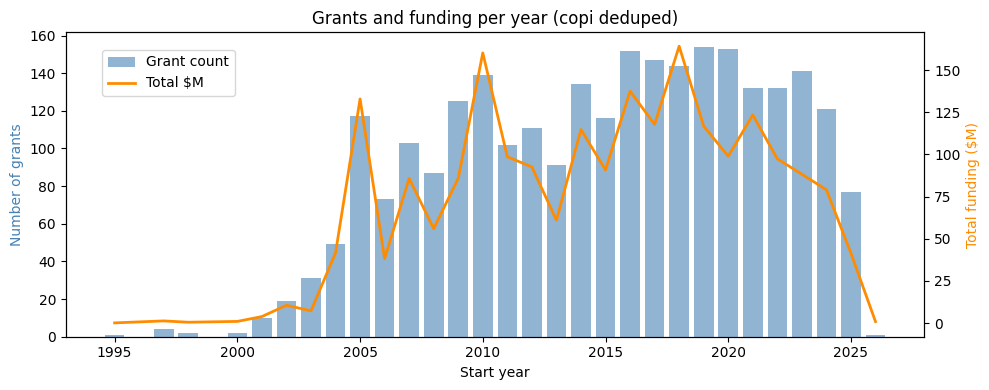

In [87]:
# Grants per year, trend over time
grants_per_year = copi_deduped.groupby('StartDateYear')['GrantId'].count().rename('num_grants')
dollars_per_year = copi_deduped.groupby('StartDateYear')['TotalDollars'].sum().rename('total_dollars') / 1e6

print('Grants and funding by year:')
summary_years = pd.concat([grants_per_year, dollars_per_year], axis=1)
print(summary_years.to_string())

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(grants_per_year.index, grants_per_year.values, color='steelblue', alpha=0.6, label='Grant count')
ax2.plot(dollars_per_year.index, dollars_per_year.values, color='darkorange', linewidth=2, label='Total $M')
ax1.set_xlabel('Start year')
ax1.set_ylabel('Number of grants', color='steelblue')
ax2.set_ylabel('Total funding ($M)', color='darkorange')
ax1.set_title('Grants and funding per year (copi deduped)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

In [88]:
# PI vs co-PI breakdown
copi_flag = copi['IsCoPI'].value_counts()
print('All rows (before dedup):')
print(f'  PI rows    (IsCoPI=0): {copi_flag.get(0, 0):,}')
print(f'  Co-PI rows (IsCoPI=1): {copi_flag.get(1, 0):,}')
print()

# Dollar difference between PI-led and Co-PI grants
print('Average TotalDollars by role:')
print(copi.groupby('IsCoPI')['TotalDollars'].agg(['mean','median','count']).rename(
    index={0:'PI', 1:'Co-PI'}).to_string())

# TotalDollars is the same for all people on a multi-PI grant.
# Comparing this directly overstates Co-PI grants if they tend to have more people.

All rows (before dedup):
  PI rows    (IsCoPI=0): 2,366
  Co-PI rows (IsCoPI=1): 770

Average TotalDollars by role:
               mean     median  count
IsCoPI                               
PI       742,417.71 399,616.50   2366
Co-PI  1,168,063.25 584,079.00    770


In [89]:
# Government vs non-government funding
gov = copi_deduped['IsGovernment'].value_counts()
print('IsGovernment (deduped grants):')
print(f'  Government     (1): {gov.get(1, 0):,}')
print(f'  Non-government (0): {gov.get(0, 0):,}')
print()
print('Non-government grants:')
print(copi_deduped[copi_deduped['IsGovernment']==0][['GrantName','AgencyName','TotalDollars']].to_string(index=False))

IsGovernment (deduped grants):
  Government     (1): 2,667
  Non-government (0): 3

Non-government grants:
                                                                    GrantName         AgencyName  TotalDollars
                                Perceptual reorganisation in macular disease. The Wellcome Trust        193827
               Enhancing bone quality and quantity in osteogenesis imperfecta The Wellcome Trust        206451
One Person's Food is Another's Poison: Food Allergy in the Twentieth Century. The Wellcome Trust        114309


In [90]:
# IsResearch flag breakdown
print('IsResearch flag (copi full):')
print(copi['IsResearch'].value_counts())
print()
print('Non-research grants (IsResearch=0) — sample:')
print(copi[copi['IsResearch']==0][['GrantName','AgencyName','TotalDollars']].head(10).to_string(index=False))

IsResearch flag (copi full):
IsResearch
1    2865
0     271
Name: count, dtype: int64

Non-research grants (IsResearch=0) — sample:
                                                                                                                                                                                                                                                     GrantName                                    AgencyName  TotalDollars
HIERARCHICAL COMPONENT-BASED FRAMEWORK FOR THE FORMAL VERIFICATION AND VALIDATION OF COMPLEX AEROSPACE SOFTWARE SYSTEMS Aerospace systems are comprised of numerous software components and ensuring that the individual components satisfy their requirements National Aeronautics and Space Administration         11313
Hierarchical Component-Based Framework for the Formal Verification and Validation of Complex Aerospace Software Systems Aerospace systems are comprised of numerous software components and ensuring that the individual components satisfy th

In [91]:
# Faculty who are in grants data vs not — gap analysis
# Only meaningful for tenure-track faculty (they are expected to bring in grants)
tenure_faculty = faculty[faculty['Academic Track Type'] == 'Tenure Track']['Employee ID']
funded_faculty = set(copi_deduped['ClientFacultyId'].values)

tenure_in_grants  = tenure_faculty.isin(funded_faculty).sum()
tenure_not_funded = (~tenure_faculty.isin(funded_faculty)).sum()

print(f'Current Tenure Track faculty  : {len(tenure_faculty):,}')
print(f'  Appear in grant records     : {tenure_in_grants:,}  ({tenure_in_grants/len(tenure_faculty)*100:.1f}%)')
print(f'  No grant record found       : {tenure_not_funded:,}  ({tenure_not_funded/len(tenure_faculty)*100:.1f}%)')
print()

# grant data only covers funded projects; absence does not mean no attempts.
# data spans 1995-2026 — newer faculty may not have had time to secure grants.

Current Tenure Track faculty  : 958
  Appear in grant records     : 486  (50.7%)
  No grant record found       : 472  (49.3%)



In [92]:
print('  DATA SUMMARY — NORTHEASTERN FUNDING DATASET')

print(f'  Time range                    : 1995 – 2026')
print()
print('  FACULTY FILE')
print(f'    Total faculty               : {len(faculty):,}')
print(f'    Unique colleges             : {faculty["Superior_Academic_Unit"].nunique()}')
print(f'    Tenure track                : {(faculty["Academic Track Type"]=="Tenure Track").sum():,}')
print(f'    Non-tenure                  : {(faculty["Academic Track Type"]=="Non-Tenure").sum():,}')
print(f'    Tenure Status null          : {faculty["Tenure Status"].isnull().sum():,}  (57%)')
print()
print('  COPI FILE (primary grant file)')
print(f'    Total rows                  : {len(copi):,}')
print(f'    Unique grants               : {copi["GrantId"].nunique():,}')
print(f'    Unique PIs                  : {copi["PersonName"].nunique():,}')
print(f'    Unique agencies             : {copi["AgencyName"].nunique()}')
print(f'    Total funding (deduped)     : ${copi_deduped["TotalDollars"].sum()/1e6:,.1f}M')
print(f'    PI rows                     : {(copi["IsCoPI"]==0).sum():,}')
print(f'    Co-PI rows                  : {(copi["IsCoPI"]==1).sum():,}')
print(f'    AwardDate populated         : {copi["AwardDate"].notna().sum()} / {len(copi):,}  (98% null)')
print(f'    Faculty match rate          : {matched_copi.sum():,} / {len(copi):,}  (94%)')
print()
print('  ABSTRACT FILE')
print(f'    Total rows                  : {len(abstract):,}')
print(f'    AA source rows (usable)     : {(abstract["Sourcetype"]=="AA").sum():,}')
print(f'    Institution rows ($0, skip) : {(abstract["Sourcetype"]=="Institution").sum():,}')
print(f'    Rows with abstract text     : {abstract["Abstract"].notna().sum():,}  (36% of total)')
print(f'    Sponsor column              : 100% null — unusable')
print(f'    Duplicate (person+title)    : {dup_abstract_person_title.sum():,}')
print()
print('  RI_MATCHES FILE')
print(f'    Total rows                  : {len(ri):,}')
print(f'    Unique grants               : {ri["grantid"].nunique():,}')
print(f'    Overlap with copi           : {len(in_both):,} / {len(copi_grant_ids):,} grants')
print(f'    Faculty match (AAUID)       : 6 / {len(ri):,}  — wrong ID system, do not join')

  DATA SUMMARY — NORTHEASTERN FUNDING DATASET
  Time range                    : 1995 – 2026

  FACULTY FILE
    Total faculty               : 2,232
    Unique colleges             : 12
    Tenure track                : 958
    Non-tenure                  : 1,079
    Tenure Status null          : 1,274  (57%)

  COPI FILE (primary grant file)
    Total rows                  : 3,136
    Unique grants               : 2,670
    Unique PIs                  : 567
    Unique agencies             : 21
    Total funding (deduped)     : $2,149.0M
    PI rows                     : 2,366
    Co-PI rows                  : 770
    AwardDate populated         : 49 / 3,136  (98% null)
    Faculty match rate          : 2,959 / 3,136  (94%)

  ABSTRACT FILE
    Total rows                  : 8,075
    AA source rows (usable)     : 3,583
    Institution rows ($0, skip) : 4,492
    Rows with abstract text     : 2,873  (36% of total)
    Sponsor column              : 100% null — unusable
    Duplicate (pers

In [102]:
# Search for a PI or co-PI
def search_person(name):
    query = name.strip().lower()
    
    results = copi[
        copi['PersonName'].str.lower().str.contains(query, na=False) |
        copi['PI'].str.lower().str.contains(query, na=False)
    ][['PersonName', 'PI', 'IsCoPI', 'GrantName', 'AgencyName', 'TotalDollars', 'StartDate']].copy()
    
    results['Role'] = results['IsCoPI'].map({0: 'PI', 1: 'Co-PI'})
    results = results.drop(columns='IsCoPI').sort_values('StartDate')
    
    print(f'Results for "{name}": {len(results)} grant rows\n')
    print(results.to_string(index=False))

search_person("Enrico")

Results for "Enrico": 8 grant rows

     PersonName                    PI                                                                                                         GrantName                      AgencyName  TotalDollars  StartDate  Role
BERTINI, ENRICO       Enrico  Bertini                    CRI: II-New: An Infrastructure of Display Devices to Study Visual Analytics Beyond the Desktop     National Science Foundation        273552 2017-09-01    PI
BERTINI, ENRICO GOLD, HEATHER TAFFET  Development and evaluation of patient-reported outcome score visualization to improve their utilization  (PROVIZ) Dept. Health and Human Services        293981 2019-09-30 Co-PI
BERTINI, ENRICO       Enrico  Bertini                CHS: Medium: Collaborative Research: Empirically Validated Perceptual Tasks for Data Visualization     National Science Foundation        402405 2019-10-01    PI
BERTINI, ENRICO       Enrico  Bertini                                            RAPID: Visualizing Epid